# F1 Pit Stop Prediction — Kaggle Playground Series S6E5

Binary classification: predict whether an F1 driver will pit on the **next lap** (`PitNextLap`).  
Metric: **AUC-ROC**

### Approach
1. Feature engineering on lap-level telemetry (lag, rolling, stint, race-context features)
2. Out-of-fold target encoding for Driver, Race, Race×Year
3. GroupKFold(5) by Race×Year to prevent within-race leakage
4. Optuna hyperparameter search on 3-fold CV (fast), then 5-fold with best params
5. LightGBM + XGBoost + CatBoost rank-average ensemble

### External dataset
Add `f1-strategy-dataset` (f1_strategy_dataset_v4.csv) as an additional Kaggle dataset for a +0.015 AUC boost.

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'optuna', '-q'], check=False)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', 'optuna', '-q'], returncode=0)

In [2]:
import warnings, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.optimize import minimize
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print('Libraries loaded.')

Libraries loaded.


## Configuration

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
INPUT_DIR = Path('/kaggle/input/competitions/playground-series-s6e5')
EXT_DIRS  = [
    Path('/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction'),
]

# ── CV / training config ─────────────────────────────────────────────────────
N_SPLITS     = 5
SEED         = 42
EXT_WEIGHT   = 0.8    # down-weight external rows (different driver encoding)

# ── Optuna config ─────────────────────────────────────────────────────────────
# Set RUN_OPTUNA = False to skip tuning and use the pre-set params below.
# Tuning adds ~60-90 min but typically gains +0.003-0.005 AUC.
RUN_OPTUNA   = True
N_LGB_TRIALS = 20
N_XGB_TRIALS = 12
N_CAT_TRIALS = 8

TARGET = 'PitNextLap'
ID_COL = 'id'

## 1 · Data Loading

In [4]:
train = pd.read_csv(INPUT_DIR / 'train.csv')
test  = pd.read_csv(INPUT_DIR / 'test.csv')
sub   = pd.read_csv(INPUT_DIR / 'sample_submission.csv')
print(f'Train: {train.shape}  Test: {test.shape}')
print(f'Positive rate: {train[TARGET].mean():.3%}')

Train: (439140, 16)  Test: (188165, 15)
Positive rate: 19.898%


In [5]:
# External dataset — add as additional Kaggle dataset for best results
ext = None
for d in EXT_DIRS:
    for fname in ['f1_strategy_dataset_v4.csv', 'f1_strategy_dataset.csv']:
        p = d / fname
        if p.exists():
            ext = pd.read_csv(p)
            print(f'External dataset loaded from {p}: {ext.shape}')
            break
    if ext is not None:
        break

if ext is None:
    print('External dataset not found — running without it (expect ~0.015 lower AUC).')
    print('To add: Kaggle → Add Data → search "f1-strategy-dataset"')

External dataset loaded from /kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v4.csv: (101371, 16)


In [6]:
COMMON_COLS = [
    'id', 'Driver', 'Race', 'Year', 'Compound', 'PitStop',
    'LapNumber', 'Stint', 'TyreLife', 'Position',
    'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
    'RaceProgress', 'Position_Change',
]

def dedup_external(train_df, ext_df):
    key_cols = ['Driver', 'Race', 'Year', 'LapNumber']
    train_keys = set(zip(train_df['Driver'], train_df['Race'],
                         train_df['Year'], train_df['LapNumber']))
    mask = [
        (d, r, y, l) not in train_keys
        for d, r, y, l in zip(ext_df['Driver'], ext_df['Race'],
                               ext_df['Year'], ext_df['LapNumber'])
    ]
    return ext_df[mask].copy()

if ext is not None:
    ext = dedup_external(train, ext)
    ext[ID_COL] = range(-1, -len(ext) - 1, -1)
    print(f'External after dedup: {len(ext):,} unique rows')

External after dedup: 76,929 unique rows


## 2 · Feature Engineering

In [7]:
_COMPOUND_ORD = {'SOFT': 0, 'MEDIUM': 1, 'HARD': 2, 'INTERMEDIATE': 3, 'WET': 4}
_COMPOUND_MAX = {'SOFT': 20, 'MEDIUM': 30, 'HARD': 40, 'INTERMEDIATE': 25, 'WET': 20}

def build_features(df):
    df = df.sort_values(['Driver', 'Race', 'Year', 'LapNumber']).copy()
    g  = df.groupby(['Driver', 'Race', 'Year'], sort=False)

    # A: Lag features
    df['LT_lag1']      = g['LapTime (s)'].shift(1)
    df['LT_lag2']      = g['LapTime (s)'].shift(2)
    df['LTD_lag1']     = g['LapTime_Delta'].shift(1)
    df['TL_lag1']      = g['TyreLife'].shift(1)
    df['PitStop_lag1'] = g['PitStop'].shift(1)
    df['CD_lag1']      = g['Cumulative_Degradation'].shift(1)

    # A2: Rolling features (shift inside transform avoids current-lap leakage)
    df['LT_roll3_mean'] = g['LapTime (s)'].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    df['LT_roll3_std']  = g['LapTime (s)'].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).std())
    df['LT_roll5_std']  = g['LapTime (s)'].transform(
        lambda x: x.shift(1).rolling(5, min_periods=2).std())
    df['LTD_roll3_mean']= g['LapTime_Delta'].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    df['CD_roll3_mean'] = g['Cumulative_Degradation'].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean())

    # B: Stint features
    stint_max = df.groupby(['Driver','Race','Year','Stint'])['TyreLife'].transform('max')
    df['NormTyreLife']        = df['TyreLife'] / stint_max.clip(lower=1)
    df['Deg_per_lap']         = df['Cumulative_Degradation'] / df['TyreLife'].clip(lower=1)
    compound_max              = df['Compound'].map(_COMPOUND_MAX).fillna(25)
    df['TyreLife_compound_pct']= df['TyreLife'] / compound_max

    # B2: Field-wide tyre context (data-driven)
    df['field_max_tyre_life']    = df.groupby(['Race','Year','Compound'])['TyreLife'].transform('max')
    df['tyre_life_vs_field_max'] = df['TyreLife'] / df['field_max_tyre_life'].clip(lower=1)
    df['deg_acceleration']       = df['Cumulative_Degradation'] - df['CD_lag1']

    # C: Race context features
    df['EstTotalLaps']         = (df['LapNumber'] / df['RaceProgress'].clip(lower=0.01)).round()
    df['LapsRemaining']        = df['EstTotalLaps'] - df['LapNumber']
    df['LapsRemaining_clip']   = df['LapsRemaining'].clip(lower=0)
    df['LT_race_compound_mean']= df.groupby(['Race','Year','Compound'])['LapTime (s)'].transform('mean')
    df['LT_vs_pace']           = df['LapTime (s)'] - df['LT_race_compound_mean']

    # D: Interactions
    df['TL_x_Stint']              = df['TyreLife'] * df['Stint']
    df['RP_x_TL']                 = df['RaceProgress'] * df['TyreLife']
    df['LR_x_TL']                 = df['LapsRemaining'] * df['TyreLife']
    df['LT_acceleration']         = df['LapTime_Delta'] - df['LTD_lag1']
    df['Deg_x_NormTL']            = df['Cumulative_Degradation'] * df['NormTyreLife']
    df['LapsRemaining_x_NormTL']  = df['LapsRemaining_clip'] * df['NormTyreLife']

    # E: Position trend
    df['Position_lag3']  = g['Position'].shift(3)
    df['position_trend'] = df['Position'] - df['Position_lag3']

    # F: Strategic window (SHAP insight: Stint is rank-2 impact but trees learn it slowly)
    df['laps_rem_vs_compound_max'] = df['LapsRemaining_clip'] - compound_max
    df['can_finish_on_current']    = (df['laps_rem_vs_compound_max'] <= 0).astype('int8')

    # G: Flag features
    df['is_year2023']   = (df['Year'] == 2023).astype('int8')
    df['is_pretesting'] = (df['Race'] == 'Pre-Season Testing').astype('int8')
    df['is_real_driver']= (~df['Driver'].astype(str).str.match(r'^D\d+$')).astype('int8')
    df['Compound_ord']  = df['Compound'].map(_COMPOUND_ORD).fillna(5).astype('int8')

    return df


FEATURE_COLS = [
    'TyreLife', 'Stint', 'LapNumber', 'Position', 'RaceProgress',
    'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'Position_Change', 'PitStop',
    # lag / rolling
    'LT_lag1', 'LT_lag2', 'LTD_lag1', 'TL_lag1', 'PitStop_lag1', 'CD_lag1',
    'LT_roll3_mean', 'LT_roll3_std', 'LT_roll5_std', 'LTD_roll3_mean', 'CD_roll3_mean',
    # stint
    'NormTyreLife', 'TyreLife_compound_pct', 'Deg_per_lap', 'tyre_life_vs_field_max',
    # degradation
    'deg_acceleration',
    # race context
    'EstTotalLaps', 'LapsRemaining', 'LapsRemaining_clip',
    'LT_race_compound_mean', 'LT_vs_pace',
    # interactions
    'TL_x_Stint', 'RP_x_TL', 'LR_x_TL',
    'LT_acceleration', 'Deg_x_NormTL', 'LapsRemaining_x_NormTL',
    # position / strategy
    'position_trend', 'laps_rem_vs_compound_max', 'can_finish_on_current',
    # flags
    'is_year2023', 'is_pretesting', 'is_real_driver', 'Compound_ord', 'Year',
]
print(f'Feature set: {len(FEATURE_COLS)} base features (+3 target encodings = {len(FEATURE_COLS)+3} total)')

Feature set: 45 base features (+3 target encodings = 48 total)


In [8]:
%%time
print('Building features on combined frame (train + test + external)...')

train_ids = set(train[ID_COL])
test_ids  = set(test[ID_COL])

train_no_target = train.drop(columns=[TARGET], errors='ignore')
frames = [train_no_target[COMMON_COLS], test[COMMON_COLS]]
if ext is not None:
    ext_common = ext[[c for c in COMMON_COLS if c in ext.columns]].copy()
    if ID_COL not in ext_common.columns:
        ext_common[ID_COL] = ext[ID_COL].values
    ext_ids = set(ext[ID_COL])
    frames.append(ext_common)

all_df = pd.concat(frames, ignore_index=True)
all_df = build_features(all_df)

train_feat = all_df[all_df[ID_COL].isin(train_ids)].merge(
    train[[ID_COL, TARGET]], on=ID_COL, how='left')
test_feat = all_df[all_df[ID_COL].isin(test_ids)]

if ext is not None:
    ext_feat = all_df[all_df[ID_COL].isin(ext_ids)].merge(
        ext[[ID_COL, TARGET]], on=ID_COL, how='left')
else:
    ext_feat = pd.DataFrame(columns=train_feat.columns)

feature_cols = [c for c in FEATURE_COLS if c in train_feat.columns]
print(f'train_feat: {train_feat.shape}  ext_feat: {ext_feat.shape}  test_feat: {test_feat.shape}')
print(f'Active feature count: {len(feature_cols)}')

Building features on combined frame (train + test + external)...
train_feat: (439140, 52)  ext_feat: (76929, 52)  test_feat: (188165, 51)
Active feature count: 45
CPU times: user 58.3 s, sys: 767 ms, total: 59.1 s
Wall time: 59.1 s


## 3 · Out-of-Fold Target Encoding

In [9]:
def add_target_encoding(train_feat, ext_feat, test_feat, n_splits=N_SPLITS):
    groups      = train_feat['Race'].astype(str) + '_' + train_feat['Year'].astype(str)
    gkf         = GroupKFold(n_splits=n_splits)
    global_mean = train_feat[TARGET].mean()

    for col in ['Driver_TE', 'Race_TE', 'Race_Year_TE']:
        train_feat[col] = global_mean
        ext_feat[col]   = global_mean
        test_feat[col]  = global_mean

    for _, (tr_idx, val_idx) in enumerate(
            gkf.split(train_feat, train_feat[TARGET], groups)):
        tr = train_feat.iloc[tr_idx]
        driver_map = tr.groupby('Driver')[TARGET].mean()
        race_map   = tr.groupby('Race')[TARGET].mean()
        ry_map     = tr.groupby(['Race', 'Year'])[TARGET].mean()

        val = train_feat.iloc[val_idx]
        train_feat.loc[val.index, 'Driver_TE'] = val['Driver'].map(driver_map).fillna(global_mean).values
        train_feat.loc[val.index, 'Race_TE']   = val['Race'].map(race_map).fillna(global_mean).values
        ry = val[['Race', 'Year']].merge(
            ry_map.rename('_te').reset_index(), on=['Race', 'Year'], how='left'
        )['_te'].fillna(global_mean).values
        train_feat.loc[val.index, 'Race_Year_TE'] = ry

    full_driver_map = train_feat.groupby('Driver')[TARGET].mean()
    full_race_map   = train_feat.groupby('Race')[TARGET].mean()
    full_ry_map     = train_feat.groupby(['Race', 'Year'])[TARGET].mean()

    for df in [test_feat, ext_feat]:
        if len(df) == 0:
            continue
        df['Driver_TE'] = df['Driver'].map(full_driver_map).fillna(global_mean).values
        df['Race_TE']   = df['Race'].map(full_race_map).fillna(global_mean).values
        ry = df[['Race', 'Year']].merge(
            full_ry_map.rename('_te').reset_index(), on=['Race', 'Year'], how='left'
        )['_te'].fillna(global_mean).values
        df['Race_Year_TE'] = ry

    return train_feat, ext_feat, test_feat

print('Computing OOF target encodings...')
train_feat, ext_feat, test_feat = add_target_encoding(train_feat, ext_feat, test_feat)
te_cols = [c for c in ['Driver_TE', 'Race_TE', 'Race_Year_TE'] if c in train_feat.columns]
feature_cols = feature_cols + te_cols
y_true = train_feat[TARGET].values
print(f'Total feature count: {len(feature_cols)}')

Computing OOF target encodings...
Total feature count: 48


## 4 · Cross-Validation Helper

In [10]:
groups_train = train_feat['Race'].astype(str) + '_' + train_feat['Year'].astype(str)

ext_X = ext_feat[feature_cols].values if len(ext_feat) > 0 else np.zeros((0, len(feature_cols)))
ext_y = ext_feat[TARGET].values       if len(ext_feat) > 0 else np.array([])
ext_w = np.full(len(ext_feat), EXT_WEIGHT)

def run_cv(model_fn, n_splits=N_SPLITS, verbose=True):
    """GroupKFold CV. model_fn(X_tr, y_tr, w_tr, X_val, y_val) -> fitted model."""
    gkf     = GroupKFold(n_splits=n_splits)
    oof     = np.zeros(len(train_feat))
    fold_aucs = []

    for fold, (tr_idx, val_idx) in enumerate(
            gkf.split(train_feat, y_true, groups_train)):
        tr_rows  = train_feat.iloc[tr_idx]
        val_rows = train_feat.iloc[val_idx]

        X_tr = np.concatenate([tr_rows[feature_cols].values, ext_X])
        y_tr = np.concatenate([tr_rows[TARGET].values, ext_y])
        w_tr = np.concatenate([np.ones(len(tr_rows)), ext_w])
        X_val, y_val = val_rows[feature_cols].values, val_rows[TARGET].values

        model = model_fn(X_tr, y_tr, w_tr, X_val, y_val)
        preds = model.predict_proba(X_val)[:, 1]
        oof[val_idx] = preds

        auc = roc_auc_score(y_val, preds)
        fold_aucs.append(auc)
        if verbose:
            print(f'  Fold {fold+1}/{n_splits} | AUC={auc:.5f}')

    mean_auc = np.mean(fold_aucs)
    if verbose:
        print(f'  Mean CV AUC: {mean_auc:.5f}  (std={np.std(fold_aucs):.5f})')
    return oof, fold_aucs


def _run3(model_fn):
    _, aucs = run_cv(model_fn, n_splits=3, verbose=False)
    return float(np.mean(aucs))

def rank_avg(arrays):
    n = len(arrays[0])
    ranks = np.column_stack([
        pd.Series(a).rank(pct=True).values for a in arrays
    ])
    return ranks.mean(axis=1)

print('CV helpers ready.')

CV helpers ready.


## 5 · Hyperparameter Tuning (Optuna)

In [11]:
# Default params — used when RUN_OPTUNA=False or as starting point
lgb_best = {
    'num_leaves': 255, 'learning_rate': 0.05, 'min_child_samples': 20,
    'subsample': 0.8, 'subsample_freq': 1, 'colsample_bytree': 0.8,
    'reg_alpha': 0.1, 'reg_lambda': 1.0,
}
xgb_best = {
    'max_depth': 7, 'learning_rate': 0.05, 'subsample': 0.8,
    'colsample_bytree': 0.8, 'min_child_weight': 5, 'gamma': 0.1,
    'reg_alpha': 0.1, 'reg_lambda': 1.0,
}
cat_best = {
    'depth': 7, 'learning_rate': 0.05, 'l2_leaf_reg': 3,
    'subsample': 0.8, 'colsample_bylevel': 0.8,
}

if RUN_OPTUNA:
    # ── LightGBM ──────────────────────────────────────────────────────────────
    print(f'=== LightGBM Optuna ({N_LGB_TRIALS} trials, 3-fold) ===')
    t0 = time.time()

    def lgb_obj(trial):
        p = {
            'num_leaves':        trial.suggest_int('num_leaves', 63, 511),
            'learning_rate':     trial.suggest_float('learning_rate', 0.02, 0.1, log=True),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 5.0),
            'reg_lambda':        trial.suggest_float('reg_lambda', 0.0, 10.0),
            'subsample_freq': 1,
        }
        def fn(X_tr, y_tr, w_tr, X_val, y_val):
            m = lgb.LGBMClassifier(objective='binary', metric='auc', n_estimators=3000,
                                   random_state=SEED, n_jobs=-1, verbose=-1, **p)
            m.fit(X_tr, y_tr, sample_weight=w_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
            return m
        return _run3(fn)

    lgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
    lgb_study.optimize(lgb_obj, n_trials=N_LGB_TRIALS, show_progress_bar=True)
    lgb_best = lgb_study.best_params
    lgb_best['subsample_freq'] = 1
    print(f'Best LGB (3-fold): {lgb_study.best_value:.5f}  ({(time.time()-t0)/60:.1f}m)')
    print(f'Params: {lgb_best}')

    # ── XGBoost ───────────────────────────────────────────────────────────────
    print(f'\n=== XGBoost Optuna ({N_XGB_TRIALS} trials, 3-fold) ===')
    t0 = time.time()

    def xgb_obj(trial):
        p = {
            'max_depth':         trial.suggest_int('max_depth', 5, 10),
            'learning_rate':     trial.suggest_float('learning_rate', 0.02, 0.1, log=True),
            'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_weight':  trial.suggest_int('min_child_weight', 1, 20),
            'gamma':             trial.suggest_float('gamma', 0.0, 5.0),
            'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 5.0),
            'reg_lambda':        trial.suggest_float('reg_lambda', 0.0, 10.0),
        }
        def fn(X_tr, y_tr, w_tr, X_val, y_val):
            m = xgb.XGBClassifier(objective='binary:logistic', eval_metric='auc',
                                  n_estimators=3000, random_state=SEED, n_jobs=-1,
                                  tree_method='hist', verbosity=0,
                                  early_stopping_rounds=50, **p)
            m.fit(X_tr, y_tr, sample_weight=w_tr, eval_set=[(X_val, y_val)], verbose=False)
            return m
        return _run3(fn)

    xgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
    xgb_study.optimize(xgb_obj, n_trials=N_XGB_TRIALS, show_progress_bar=True)
    xgb_best = xgb_study.best_params
    print(f'Best XGB (3-fold): {xgb_study.best_value:.5f}  ({(time.time()-t0)/60:.1f}m)')
    print(f'Params: {xgb_best}')

    # ── CatBoost ──────────────────────────────────────────────────────────────
    print(f'\n=== CatBoost Optuna ({N_CAT_TRIALS} trials, 3-fold) ===')
    t0 = time.time()

    def cat_obj(trial):
        p = {
            'depth':              trial.suggest_int('depth', 5, 9),
            'learning_rate':      trial.suggest_float('learning_rate', 0.03, 0.1, log=True),
            'l2_leaf_reg':        trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
            'subsample':          trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bylevel':  trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        }
        def fn(X_tr, y_tr, w_tr, X_val, y_val):
            m = CatBoostClassifier(iterations=3000, eval_metric='AUC', random_seed=SEED,
                                   verbose=0, early_stopping_rounds=50, task_type='CPU', **p)
            m.fit(X_tr, y_tr, sample_weight=w_tr, eval_set=(X_val, y_val),
                  use_best_model=True, verbose=False)
            return m
        return _run3(fn)

    cat_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
    cat_study.optimize(cat_obj, n_trials=N_CAT_TRIALS, show_progress_bar=True)
    cat_best = cat_study.best_params
    print(f'Best CAT (3-fold): {cat_study.best_value:.5f}  ({(time.time()-t0)/60:.1f}m)')
    print(f'Params: {cat_best}')
else:
    print('Optuna skipped — using pre-set parameters.')

=== LightGBM Optuna (20 trials, 3-fold) ===


  0%|          | 0/20 [00:00<?, ?it/s]

Best LGB (3-fold): 0.94008  (58.7m)
Params: {'num_leaves': 168, 'learning_rate': 0.028605097323580003, 'min_child_samples': 61, 'subsample': 0.9002273028753416, 'colsample_bytree': 0.5684502175147322, 'reg_alpha': 1.5456841873149634, 'reg_lambda': 8.139937055778315, 'subsample_freq': 1}

=== XGBoost Optuna (12 trials, 3-fold) ===


  0%|          | 0/12 [00:00<?, ?it/s]

Best XGB (3-fold): 0.93925  (60.9m)
Params: {'max_depth': 10, 'learning_rate': 0.020219662603849067, 'subsample': 0.7294480126518945, 'colsample_bytree': 0.5085930751344795, 'min_child_weight': 12, 'gamma': 2.1717813587820562, 'reg_alpha': 4.933376106721472, 'reg_lambda': 0.10907590424461285}

=== CatBoost Optuna (8 trials, 3-fold) ===


  0%|          | 0/8 [00:00<?, ?it/s]

Best CAT (3-fold): 0.93798  (58.1m)
Params: {'depth': 8, 'learning_rate': 0.0354862109207614, 'l2_leaf_reg': 3.629301836816963, 'subsample': 0.7465447373174767, 'colsample_bylevel': 0.728034992108518}


## 6 · Full 5-Fold CV with Best Parameters

In [12]:
# ── LightGBM ──────────────────────────────────────────────────────────────────
print('=== LightGBM 5-fold CV ===')
def lgb_fn(X_tr, y_tr, w_tr, X_val, y_val):
    m = lgb.LGBMClassifier(objective='binary', metric='auc', n_estimators=3000,
                           random_state=SEED, n_jobs=-1, verbose=-1, **lgb_best)
    m.fit(X_tr, y_tr, sample_weight=w_tr, eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)])
    return m

lgb_oof, lgb_fold_aucs = run_cv(lgb_fn)
print(f'LGB OOF AUC: {roc_auc_score(y_true, lgb_oof):.5f}')

=== LightGBM 5-fold CV ===
  Fold 1/5 | AUC=0.93526
  Fold 2/5 | AUC=0.94033
  Fold 3/5 | AUC=0.95148
  Fold 4/5 | AUC=0.93951
  Fold 5/5 | AUC=0.93051
  Mean CV AUC: 0.93942  (std=0.00697)
LGB OOF AUC: 0.94004


In [13]:
# ── XGBoost ───────────────────────────────────────────────────────────────────
print('=== XGBoost 5-fold CV ===')
def xgb_fn(X_tr, y_tr, w_tr, X_val, y_val):
    m = xgb.XGBClassifier(objective='binary:logistic', eval_metric='auc', n_estimators=3000,
                          random_state=SEED, n_jobs=-1, tree_method='hist', verbosity=0,
                          early_stopping_rounds=100, **xgb_best)
    m.fit(X_tr, y_tr, sample_weight=w_tr, eval_set=[(X_val, y_val)], verbose=False)
    return m

xgb_oof, xgb_fold_aucs = run_cv(xgb_fn)
print(f'XGB OOF AUC: {roc_auc_score(y_true, xgb_oof):.5f}')

=== XGBoost 5-fold CV ===
  Fold 1/5 | AUC=0.93366
  Fold 2/5 | AUC=0.93972
  Fold 3/5 | AUC=0.95051
  Fold 4/5 | AUC=0.93875
  Fold 5/5 | AUC=0.92962
  Mean CV AUC: 0.93845  (std=0.00704)
XGB OOF AUC: 0.93922


In [14]:
# ── CatBoost ──────────────────────────────────────────────────────────────────
print('=== CatBoost 5-fold CV ===')
def cat_fn(X_tr, y_tr, w_tr, X_val, y_val):
    p = {**cat_best, 'early_stopping_rounds': 100}
    m = CatBoostClassifier(iterations=3000, eval_metric='AUC', random_seed=SEED,
                           verbose=0, task_type='CPU', **p)
    m.fit(X_tr, y_tr, sample_weight=w_tr, eval_set=(X_val, y_val),
          use_best_model=True, verbose=False)
    return m

cat_oof, cat_fold_aucs = run_cv(cat_fn)
print(f'CAT OOF AUC: {roc_auc_score(y_true, cat_oof):.5f}')

=== CatBoost 5-fold CV ===
  Fold 1/5 | AUC=0.93234
  Fold 2/5 | AUC=0.93687
  Fold 3/5 | AUC=0.95046
  Fold 4/5 | AUC=0.93805
  Fold 5/5 | AUC=0.92889
  Mean CV AUC: 0.93732  (std=0.00734)
CAT OOF AUC: 0.93793


In [15]:
# ── Rank ensemble ─────────────────────────────────────────────────────────────
rank_oof = rank_avg([lgb_oof, xgb_oof, cat_oof])
rank_auc = roc_auc_score(y_true, rank_oof)

print('\n=== OOF AUC Summary ===')
results = {
    'LGB':           roc_auc_score(y_true, lgb_oof),
    'XGB':           roc_auc_score(y_true, xgb_oof),
    'CatBoost':      roc_auc_score(y_true, cat_oof),
    'Rank Ensemble': rank_auc,
}
for name, auc in sorted(results.items(), key=lambda x: -x[1]):
    print(f'  {name:<18} {auc:.5f}')


=== OOF AUC Summary ===
  LGB                0.94004
  Rank Ensemble      0.93995
  XGB                0.93922
  CatBoost           0.93793


## 7 · Full-Train Models for Test Predictions

In [16]:
%%time
print('Training full models on all data (train + external)...')

if len(ext_feat) > 0:
    X_all = pd.concat([train_feat[feature_cols], ext_feat[feature_cols]]).values
    y_all = pd.concat([train_feat[TARGET], ext_feat[TARGET]]).values
    w_all = np.concatenate([np.ones(len(train_feat)), np.full(len(ext_feat), EXT_WEIGHT)])
else:
    X_all = train_feat[feature_cols].values
    y_all = train_feat[TARGET].values
    w_all = np.ones(len(train_feat))

X_test = test_feat[feature_cols].values
N_EST  = 1500  # fixed n_estimators for full-train (no early stopping)

print('  LGB...')
lgb_full = lgb.LGBMClassifier(objective='binary', metric='auc', n_estimators=N_EST,
                               random_state=SEED, n_jobs=-1, verbose=-1, **lgb_best)
lgb_full.fit(X_all, y_all, sample_weight=w_all)
lgb_test = lgb_full.predict_proba(X_test)[:, 1]

print('  XGB...')
xgb_full = xgb.XGBClassifier(objective='binary:logistic', eval_metric='auc', n_estimators=N_EST,
                              random_state=SEED, n_jobs=-1, tree_method='hist', verbosity=0, **xgb_best)
xgb_full.fit(X_all, y_all, sample_weight=w_all)
xgb_test = xgb_full.predict_proba(X_test)[:, 1]

print('  CatBoost...')
cat_full = CatBoostClassifier(iterations=N_EST, eval_metric='AUC', random_seed=SEED,
                              verbose=0, task_type='CPU', **cat_best)
cat_full.fit(X_all, y_all, sample_weight=w_all)
cat_test = cat_full.predict_proba(X_test)[:, 1]

print('Done.')

Training full models on all data (train + external)...
  LGB...
  XGB...
  CatBoost...
Done.
CPU times: user 24min 20s, sys: 40 s, total: 25min
Wall time: 6min 21s


In [17]:
# ── LGB DART ─────────────────────────────────────────────────────────────────
print('=== LGB DART mode ===')
dart_params = {**lgb_best, 'boosting_type': 'dart', 'drop_rate': 0.1, 'skip_drop': 0.5,
               'n_estimators': 600}

def dart_fn(X_tr, y_tr, w_tr, X_val, y_val):
    m = lgb.LGBMClassifier(objective='binary', metric='auc', random_state=SEED,
                           n_jobs=-1, verbose=-1, **dart_params)
    m.fit(X_tr, y_tr, sample_weight=w_tr, callbacks=[lgb.log_evaluation(-1)])
    return m

dart_oof, _ = run_cv(dart_fn)
print(f'LGB DART OOF AUC: {roc_auc_score(y_true, dart_oof):.5f}')

dart_full = lgb.LGBMClassifier(objective='binary', metric='auc', random_state=SEED,
                               n_jobs=-1, verbose=-1, **dart_params)
dart_full.fit(X_all, y_all, sample_weight=w_all)
dart_test = dart_full.predict_proba(X_test)[:, 1]

=== LGB DART mode ===
  Fold 1/5 | AUC=0.92724
  Fold 2/5 | AUC=0.93631
  Fold 3/5 | AUC=0.94606
  Fold 4/5 | AUC=0.93492
  Fold 5/5 | AUC=0.92748
  Mean CV AUC: 0.93440  (std=0.00692)
LGB DART OOF AUC: 0.93506


## 8 · Final Ensemble

In [18]:
def optimise_weights(oof_preds, y_true):
    n = len(oof_preds)
    def neg_auc(w):
        w = np.abs(w) / np.abs(w).sum()
        blend = sum(wi * p for wi, p in zip(w, oof_preds))
        return -roc_auc_score(y_true, blend)
    res = minimize(neg_auc, x0=np.ones(n)/n, method='Nelder-Mead',
                   options={'maxiter': 2000, 'xatol': 1e-6})
    w = np.abs(res.x) / np.abs(res.x).sum()
    return w

all_oofs  = [lgb_oof, xgb_oof, cat_oof, dart_oof]
all_tests = [lgb_test, xgb_test, cat_test, dart_test]

# Rank average (4 models)
rank4_oof  = rank_avg(all_oofs)
rank4_test = rank_avg(all_tests)
print(f'Rank 4-model OOF AUC: {roc_auc_score(y_true, rank4_oof):.5f}')

# Optimised weighted blend
w_opt = optimise_weights(all_oofs, y_true)
print(f'Weights: LGB={w_opt[0]:.3f} XGB={w_opt[1]:.3f} CAT={w_opt[2]:.3f} DART={w_opt[3]:.3f}')
weighted_oof  = sum(wi * p for wi, p in zip(w_opt, all_oofs))
weighted_test = sum(wi * p for wi, p in zip(w_opt, all_tests))
print(f'Weighted blend OOF AUC: {roc_auc_score(y_true, weighted_oof):.5f}')

# Stacking (LR meta-learner)
gkf = GroupKFold(n_splits=N_SPLITS)
meta_tr = np.column_stack(all_oofs)
meta_te = np.column_stack(all_tests)
stacked_oof  = np.zeros(len(y_true))
stacked_test = np.zeros(len(meta_te))
for tr_idx, val_idx in gkf.split(meta_tr, y_true, groups_train):
    lr = LogisticRegression(C=1.0, max_iter=1000)
    lr.fit(meta_tr[tr_idx], y_true[tr_idx])
    stacked_oof[val_idx]  = lr.predict_proba(meta_tr[val_idx])[:, 1]
    stacked_test         += lr.predict_proba(meta_te)[:, 1] / N_SPLITS
print(f'Stacked (LR meta) OOF AUC: {roc_auc_score(y_true, stacked_oof):.5f}')

# Final comparison
all_ensemble = {
    'LGB':                   roc_auc_score(y_true, lgb_oof),
    'XGB':                   roc_auc_score(y_true, xgb_oof),
    'CatBoost':              roc_auc_score(y_true, cat_oof),
    'LGB DART':              roc_auc_score(y_true, dart_oof),
    'Rank 3-model':          roc_auc_score(y_true, rank_avg([lgb_oof, xgb_oof, cat_oof])),
    'Rank 4-model (+DART)':  roc_auc_score(y_true, rank4_oof),
    'Weighted 4-model':      roc_auc_score(y_true, weighted_oof),
    'Stacked (LR meta)':     roc_auc_score(y_true, stacked_oof),
}
print('\n=== Final OOF AUC Comparison ===')
for k, v in sorted(all_ensemble.items(), key=lambda x: -x[1]):
    print(f'  {k:<26} {v:.5f}')

best_method = max(all_ensemble, key=all_ensemble.get)
print(f'\nBest: {best_method}')

if 'Stacked' in best_method:
    final_preds = stacked_test
elif 'Weighted' in best_method:
    final_preds = weighted_test
elif '4-model' in best_method:
    final_preds = rank4_test
else:
    final_preds = rank4_test

Rank 4-model OOF AUC: 0.93943
Weights: LGB=0.724 XGB=0.105 CAT=0.171 DART=0.000
Weighted blend OOF AUC: 0.94019
Stacked (LR meta) OOF AUC: 0.93848

=== Final OOF AUC Comparison ===
  Weighted 4-model           0.94019
  LGB                        0.94004
  Rank 3-model               0.93995
  Rank 4-model (+DART)       0.93943
  XGB                        0.93922
  Stacked (LR meta)          0.93848
  CatBoost                   0.93793
  LGB DART                   0.93506

Best: Weighted 4-model


## 9 · Feature Importance

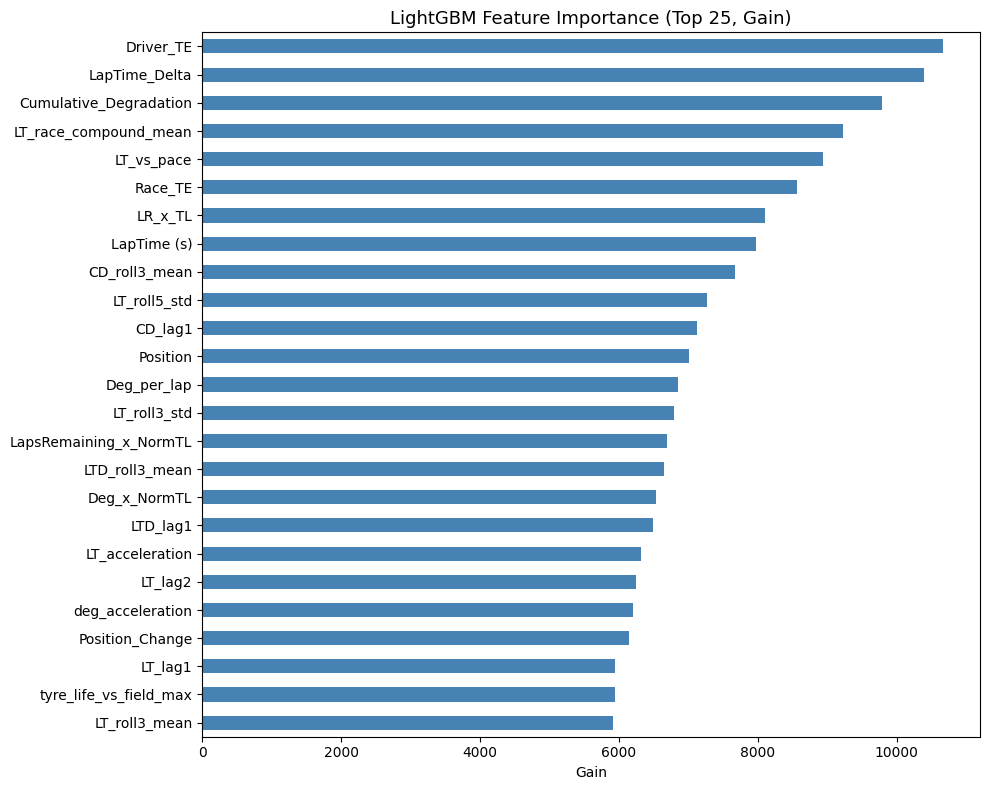


Top 15 features by gain:
Driver_TE                 10664
LapTime_Delta             10396
Cumulative_Degradation     9784
LT_race_compound_mean      9229
LT_vs_pace                 8933
Race_TE                    8557
LR_x_TL                    8096
LapTime (s)                7977
CD_roll3_mean              7676
LT_roll5_std               7264
CD_lag1                    7126
Position                   7003
Deg_per_lap                6844
LT_roll3_std               6785
LapsRemaining_x_NormTL     6689


In [19]:
fi = pd.Series(lgb_full.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
fi.head(25).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('LightGBM Feature Importance (Top 25, Gain)', fontsize=13)
ax.set_xlabel('Gain')
plt.tight_layout()
plt.show()

print('\nTop 15 features by gain:')
print(fi.head(15).to_string())

## 10 · Pseudo-Labeling (Optional Boost)

In [20]:
HIGH_THRESH = 0.90
LOW_THRESH  = 0.05
PL_WEIGHT   = 0.5

high_conf = (final_preds > HIGH_THRESH) | (final_preds < LOW_THRESH)
pseudo = test_feat[high_conf].copy()
pseudo[TARGET] = (final_preds[high_conf] > 0.5).astype(int)
n_pos = (pseudo[TARGET] == 1).sum()
print(f'Pseudo-labels: {len(pseudo):,} rows  ({n_pos:,} positive, {len(pseudo)-n_pos:,} negative)')

if len(ext_feat) > 0:
    ext_pl = pd.concat([ext_feat, pseudo], ignore_index=True)
else:
    ext_pl = pseudo.copy()

ext_pl_X = ext_pl[feature_cols].values
ext_pl_y = ext_pl[TARGET].values
ext_pl_w = np.full(len(ext_pl), PL_WEIGHT)

def lgb_pl_fn(X_tr, y_tr, w_tr, X_val, y_val):
    m = lgb.LGBMClassifier(objective='binary', metric='auc', n_estimators=3000,
                           random_state=SEED, n_jobs=-1, verbose=-1, **lgb_best)
    m.fit(X_tr, y_tr, sample_weight=w_tr, eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)])
    return m

# Temporarily override ext arrays for pseudo-labeled run
_ext_X, _ext_y, _ext_w = ext_X, ext_y, ext_w
ext_X, ext_y, ext_w = ext_pl_X, ext_pl_y, ext_pl_w

lgb_oof_pl, _ = run_cv(lgb_pl_fn)
pl_auc = roc_auc_score(y_true, lgb_oof_pl)
print(f'LGB OOF AUC with pseudo-labels: {pl_auc:.5f}')

ext_X, ext_y, ext_w = _ext_X, _ext_y, _ext_w  # restore

if pl_auc > all_ensemble['LGB']:
    print('Pseudo-labeling improved LGB — training full model...')
    X_pl = np.concatenate([train_feat[feature_cols].values, ext_pl_X])
    y_pl = np.concatenate([train_feat[TARGET].values, ext_pl_y])
    w_pl = np.concatenate([np.ones(len(train_feat)), ext_pl_w])
    lgb_pl_full = lgb.LGBMClassifier(objective='binary', metric='auc', n_estimators=1500,
                                     random_state=SEED, n_jobs=-1, verbose=-1, **lgb_best)
    lgb_pl_full.fit(X_pl, y_pl, sample_weight=w_pl)
    lgb_test_pl = lgb_pl_full.predict_proba(X_test)[:, 1]
    all_tests_pl = [lgb_test_pl, xgb_test, cat_test, dart_test]
    final_preds_pl = rank_avg(all_tests_pl)
    pl_rank_oof = rank_avg([lgb_oof_pl, xgb_oof, cat_oof, dart_oof])
    print(f'Rank ensemble with PL-LGB OOF AUC: {roc_auc_score(y_true, pl_rank_oof):.5f}')
    if roc_auc_score(y_true, pl_rank_oof) > all_ensemble[best_method]:
        final_preds = final_preds_pl
        print('Using pseudo-labeled ensemble as final submission.')
else:
    print('Pseudo-labeling did not improve — keeping original ensemble.')

Pseudo-labels: 122,236 rows  (9,985 positive, 112,251 negative)
  Fold 1/5 | AUC=0.93428
  Fold 2/5 | AUC=0.93980
  Fold 3/5 | AUC=0.95072
  Fold 4/5 | AUC=0.93900
  Fold 5/5 | AUC=0.93026
  Mean CV AUC: 0.93881  (std=0.00688)
LGB OOF AUC with pseudo-labels: 0.93952
Pseudo-labeling did not improve — keeping original ensemble.


## 11 · Submission

In [21]:
submission = pd.DataFrame({
    'id':          test_feat[ID_COL].values,
    TARGET:        final_preds,
})

# Sanity checks
assert len(submission) == len(sub), f'Row mismatch: {len(submission)} vs {len(sub)}'
assert submission[TARGET].between(0, 1).all(), 'Predictions out of [0,1] range'
assert submission['id'].nunique() == len(submission), 'Duplicate IDs'

submission.to_csv('submission.csv', index=False)
print(f'submission.csv saved: {len(submission):,} rows')
print(f'Prediction mean: {submission[TARGET].mean():.4f}  std: {submission[TARGET].std():.4f}')
submission.head()

submission.csv saved: 188,165 rows
Prediction mean: 0.2083  std: 0.3122


,id,PitNextLap
0,496081,0.008472
1,476804,0.008248
2,505009,0.588753
3,475620,0.004336
4,616284,0.001855


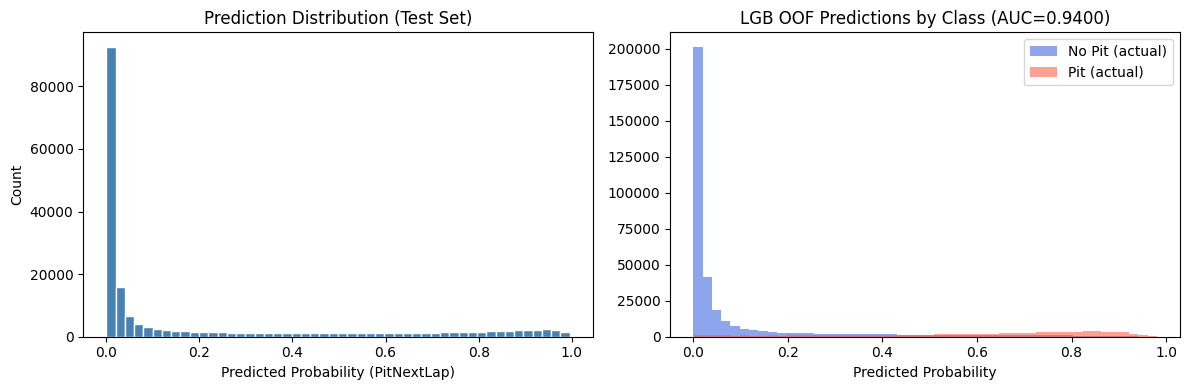

In [22]:
# Prediction distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(submission[TARGET], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Prediction Distribution (Test Set)')
axes[0].set_xlabel('Predicted Probability (PitNextLap)')
axes[0].set_ylabel('Count')

axes[1].hist(lgb_oof[y_true == 0], bins=50, alpha=0.6, label='No Pit (actual)', color='royalblue')
axes[1].hist(lgb_oof[y_true == 1], bins=50, alpha=0.6, label='Pit (actual)', color='tomato')
axes[1].set_title(f'LGB OOF Predictions by Class (AUC={roc_auc_score(y_true, lgb_oof):.4f})')
axes[1].set_xlabel('Predicted Probability')
axes[1].legend()

plt.tight_layout()
plt.show()